In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append('/home/jovyan/work/tactics_demo')

In [4]:
# 设置标的和日期
instrument_id = '511090'
trade_ymd = '20251219'

# 策略参数配置
param_dict = {
    'instrument_id': instrument_id,
    'trade_ymd': trade_ymd,
    'name': 'delta_v1_demo',
    'stride': 1,

    'short_window': 60,      # 短期窗口
    'long_window': 300,      # 长期窗口
    'y_window': 300,         # 标签窗口

    'open_threshold': 2,     # 开仓阈值
    'open_confidence': 0,    # 开仓置信度
    'close_threshold': 3,    # 平仓阈值
    'close_confidence': 1,   # 平仓置信度
    'standard_num': 1000,    # 标准数量

    'atr_multiplier': 4,     # 回撤比例
    'vol_window': 900,       # 价格波动窗口

    'k_up': 3,
    'k_down': 3,
}
param_dict['x_window'] = max(param_dict['short_window'], param_dict['long_window'])

In [5]:
model_path = f"/home/jovyan/work/model/delta_{instrument_id}.pkl"
import joblib
model = joblib.load(model_path)
print(f"模型已加载: {model_path}")

模型已加载: /home/jovyan/work/model/delta_511090.pkl


In [6]:
from delta import strategy 
tactic = strategy.StrategyDemo(model_path, param_dict)

In [7]:
# 单日回测测试
sys.path.append('/home/jovyan/base_demo')
import base_tool
snap_list = base_tool.snap_list_load(instrument_id, trade_ymd)

position_dict = {}
for snap in snap_list:
    tactic.on_snap(snap)
    position_dict[snap['time_mark']] = tactic.position_last

print(f"生成 {len(position_dict)} 个仓位信号")

生成 14402 个仓位信号


-> Python解释器: /opt/conda/bin/python
-> Python版本: 3.13.11 | packaged by conda-forge | (main, Jan 26 2026, 23:57:06) [GCC 14.3.0]
spawn模式启动
-> 当前 Python 解释器: /opt/conda/bin/python
-> 从delta/train.py获取到 57 个有数据的交易日
-> 过滤后剩余 23 个有数据的交易日
-> 过滤掉 8 个无数据日期: ['20251206', '20251207', '20251213', '20251214', '20251220', '20251221', '20251227', '20251228']
-> 回测标的: 511090 (20251201 - 20251231)
-> 任务分配: 共 23 天，使用 4 个核心并行计算...


[SpawnPoolWorker-1] 日期 20251201 完成 | 盈亏: 19.50 | 成交: 8次 | 胜率: 75.0% | 平均持仓: 1416.6快照
[SpawnPoolWorker-3] 日期 20251225 完成 | 盈亏: -8.00 | 成交: 11次 | 胜率: 36.4% | 平均持仓: 978.1快照
[SpawnPoolWorker-4] 日期 20251217 完成 | 盈亏: 30.00 | 成交: 9次 | 胜率: 55.6% | 平均持仓: 1258.7快照
[SpawnPoolWorker-2] 日期 20251209 完成 | 盈亏: -37.00 | 成交: 13次 | 胜率: 30.8% | 平均持仓: 928.8快照
[SpawnPoolWorker-1] 日期 20251202 完成 | 盈亏: 43.40 | 成交: 6次 | 胜率: 100.0% | 平均持仓: 1691.3快照
[SpawnPoolWorker-3] 日期 20251226 完成 | 盈亏: -27.40 | 成交: 16次 | 胜率: 18.8% | 平均持仓: 680.8快照
[SpawnPoolWorker-4] 日期 20251218 完成 | 盈亏: 42.50 | 成交: 7次 | 胜率: 42.9% | 平均持仓: 1643.7快照
[SpawnPoolWorker-2] 日期 20251210 完成 | 盈亏: -10.50 | 成交: 10次 | 胜率: 40.0% | 平均持仓: 1190.4快照
[SpawnPoolWorker-1] 日期 20251203 完成 | 盈亏: 40.70 | 成交: 7次 | 胜率: 71.4% | 平均持仓: 1595.7快照
[SpawnPoolWorker-3] 日期 20251229 完成 | 盈亏: 16.50 | 成交: 7次 | 胜率: 57.1% | 平均持仓: 1646.7快照
[SpawnPoolWorker-4] 日期 20251219 完成 | 盈亏: 25.40 | 成交: 9次 | 胜率: 55.6% | 平均持仓: 1275.3快照
[SpawnPoolWorker-2] 日期 20251211 完成 | 盈亏: -20.50 | 成交: 13次 | 

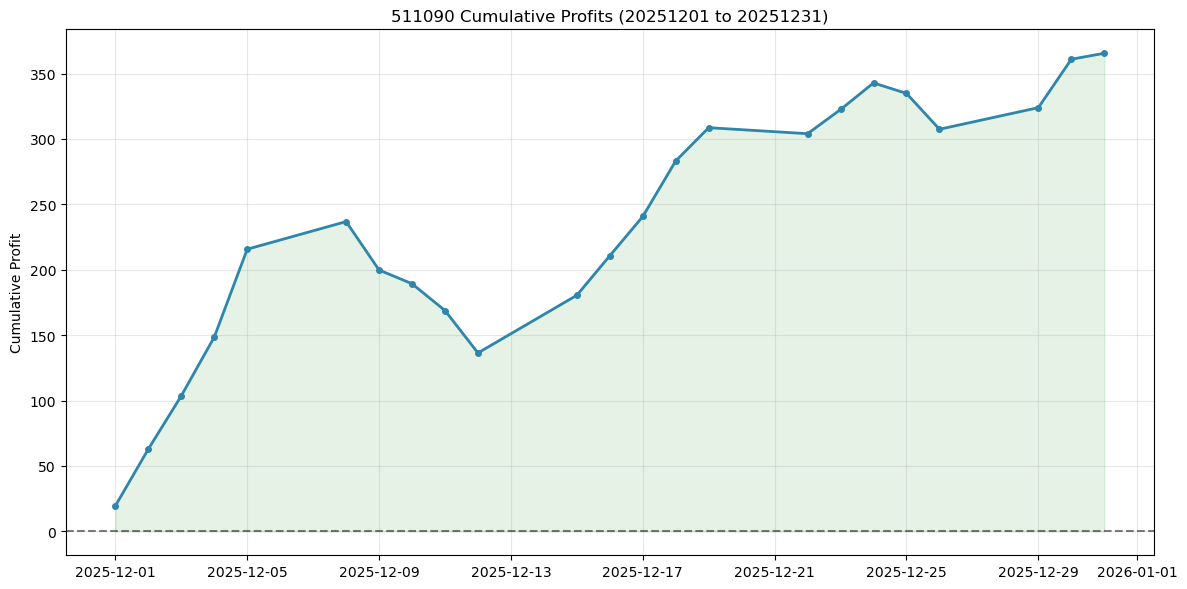


并行回测结果汇总:


In [8]:
sys.path.append('/home/jovyan/work/tactics_demo/tools')
from tools.parallel_backtest_simple import run_parallel_backtest
from tools.multi_day_backtest import backtest_summary

result_df = run_parallel_backtest(
    instrument_id=instrument_id,
    start_ymd="20251201",
    end_ymd="20251231",
    StrategyClass=strategy.StrategyDemo,
    model=model_path,
    param_dict=param_dict,
    n_cores=4
)


print("\n并行回测结果汇总:")
summary = backtest_summary(result_df)